In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import kagglehub


In [ ]:
DATASET_PATH = Path("~/.cache/kagglehub/datasets/harikrishnacs/"
                    "sentinel-1-sar-oil-spill-detection-dataset/versions/1").expanduser()
IMG_SIZE     = 224
BATCH_SIZE   = 16
LR           = 1e-4
EPOCHS       = 140
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.10
SEED         = 42
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
# ════════════════════════════════════════════
# BLOC 2 — Téléchargement du dataset
# ════════════════════════════════════════════

path = kagglehub.dataset_download("harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset")
root = Path(path + "/data/S1SAR_UnBalanced_400by400_Class_")
print(f"Dataset : {root}")

100%|██████████| 65.3M/65.3M [00:00<00:00, 240MB/s]

Extracting files...


Dataset : /root/.cache/kagglehub/datasets/harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset/versions/1/data/S1SAR_UnBalanced_400by400_Class_


In [ ]:
# ════════════════════════════════════════════
# BLOC 3 — Liste de toutes les images
# ════════════════════════════════════════════

items = []
for label in [0, 1]:
    folder = Path(str(root) + str(label) + "/" + str(label))
    files  = sorted(folder.glob("*.jpg"))
    items += [(f, label) for f in files]

random.shuffle(items)

n0 = sum(1 for _, l in items if l == 0)
n1 = sum(1 for _, l in items if l == 1)
print(f"Classe 0 (sans huile) : {n0} images")
print(f"Classe 1 (avec huile) : {n1} images")
print(f"Total                 : {len(items)} images")

Classe 0 (sans huile) : 3725 images
Classe 1 (avec huile) : 1905 images
Total                 : 5630 images


OpenCV img = cv2.imread(path) loads an image with HWC-layout (height, width, channels), while Pytorch requires CHW-layout. So we have to do np.transpose(image,(2,0,1)) for HWC->CHW transformation.

In [ ]:
# ════════════════════════════════════════════
# BLOC 4 — Chargement et normalisation
# ════════════════════════════════════════════

def load_image(path):
    """Charge une image JPG et la normalise."""
    img = Image.open(path).convert("RGB").resize((224, 224))  # resize ici
    img = np.array(img).astype(np.float32) / 255.0            # converti depuis l'image redimensionnée
    img = img.transpose(2, 0, 1)                              # (3, 128, 128)

    # Z-score par canal
    for c in range(img.shape[0]):
        mu     = img[c].mean()
        std    = img[c].std() + 1e-6
        img[c] = (img[c] - mu) / std

    return img

# Test sur une image pour vérifier
img_test, label_test = items[0]
img_array = load_image(img_test)
print(f"Shape image chargée : {img_array.shape}")
print(f"Label               : {label_test}")
print(f"Valeurs min/max     : {img_array.min():.2f} / {img_array.max():.2f}")


Shape image chargée : (3, 224, 224)
Label               : 1
Valeurs min/max     : -10.98 / 5.09


In [ ]:
# ════════════════════════════════════════════
# BLOC 5 — Chargement de tout le dataset en mémoire
# ════════════════════════════════════════════

print("Chargement de toutes les images...")

all_images = []
all_labels = []

for img_path, label in items:
    img = load_image(img_path)
    all_images.append(img)
    all_labels.append(label)

# Conversion en tenseurs PyTorch
X = torch.tensor(np.array(all_images), dtype=torch.float32)  # (N, 3, 400, 400)
y = torch.tensor(all_labels,           dtype=torch.float32)  # (N,)

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")

Chargement de toutes les images...
Shape X : torch.Size([5630, 3, 224, 224])
Shape y : torch.Size([5630])


In [ ]:
# ════════════════════════════════════════════
# BLOC 6 — Découpage train / val / test
# ════════════════════════════════════════════

dataset = TensorDataset(X, y)

n_total = len(dataset)
n_test  = int(n_total * TEST_SPLIT)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val - n_test

train_ds, val_ds, test_ds = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train : {n_train} | Val : {n_val} | Test : {n_test}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

Train : 4223 | Val : 844 | Test : 563


In [ ]:
print(DEVICE)
print(torch.cuda.is_available())

cuda
True


In [ ]:
# ════════════════════════════════════════════
# BLOC 7 — Modèle CNN
# ════════════════════════════════════════════

model = nn.Sequential(
    # Bloc 1 :
    nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),

    # Bloc 2 :
    nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),

    # Bloc 3 :
    nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),

    # Bloc 4 :
    nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),

     # Bloc 5 :
    nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(512), # Changed from 256 to 512
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),

     # Bloc 6 :
    nn.Conv2d(512, 1024, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(1024), # Changed from 256 to 1024
    nn.ReLU(inplace=True),
    nn.MaxPool2d(2),

    # Global Average Pooling :
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),

    # Classifieur
    nn.Linear(1024, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(512, 1),
)

model = model.to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {n_params:,}")


Paramètres entraînables : 6,815,521


In [ ]:
# ════════════════════════════════════════════
# BLOC 8 — Entraînement
# ════════════════════════════════════════════

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_acc = 0

for epoch in range(1, EPOCHS + 1):

    # ── Train ──
    model.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # ── Validation ──
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs).squeeze(1)
            val_loss += criterion(logits, labels).item()
            preds    = (torch.sigmoid(logits) > 0.5).float()
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    val_acc     = correct / total
    #scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Loss train={train_loss:.4f} val={val_loss:.4f} | "
          f"Accuracy val={val_acc:.3f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  ✓ Meilleur modèle sauvegardé (acc={best_acc:.3f})")


Epoch 01/140 | Loss train=0.6639 val=0.6302 | Accuracy val=0.695
  ✓ Meilleur modèle sauvegardé (acc=0.695)
Epoch 02/140 | Loss train=0.6357 val=0.6034 | Accuracy val=0.695
Epoch 03/140 | Loss train=0.6163 val=0.5813 | Accuracy val=0.697
  ✓ Meilleur modèle sauvegardé (acc=0.697)
Epoch 04/140 | Loss train=0.5955 val=0.5605 | Accuracy val=0.727
  ✓ Meilleur modèle sauvegardé (acc=0.727)
Epoch 05/140 | Loss train=0.5761 val=0.5357 | Accuracy val=0.763
  ✓ Meilleur modèle sauvegardé (acc=0.763)
Epoch 06/140 | Loss train=0.5578 val=0.5118 | Accuracy val=0.812
  ✓ Meilleur modèle sauvegardé (acc=0.812)
Epoch 07/140 | Loss train=0.5312 val=0.4938 | Accuracy val=0.841
  ✓ Meilleur modèle sauvegardé (acc=0.841)
Epoch 08/140 | Loss train=0.5142 val=0.4656 | Accuracy val=0.867
  ✓ Meilleur modèle sauvegardé (acc=0.867)
Epoch 09/140 | Loss train=0.4903 val=0.4430 | Accuracy val=0.868
  ✓ Meilleur modèle sauvegardé (acc=0.868)
Epoch 10/140 | Loss train=0.4694 val=0.4233 | Accuracy val=0.872
  ✓ Me

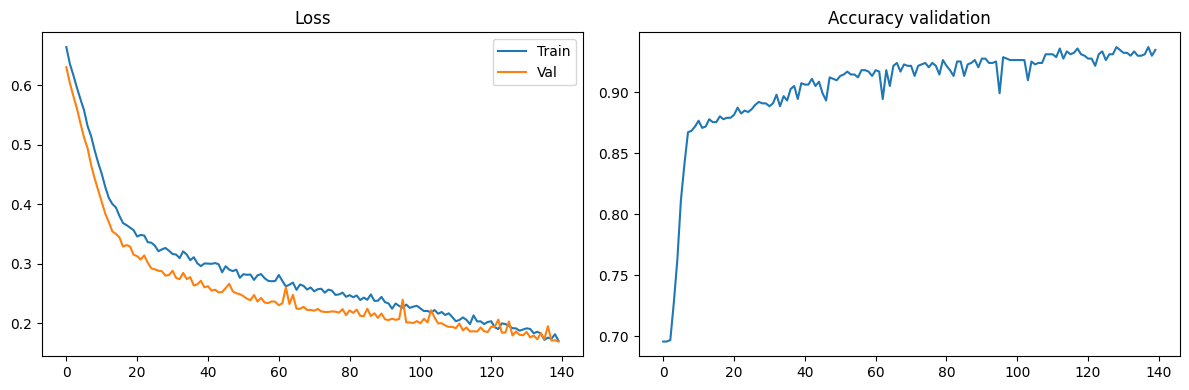

In [ ]:
# ════════════════════════════════════════════
# BLOC 9 — Courbes d'apprentissage
# ════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["val_acc"])
axes[1].set_title("Accuracy validation")

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

continue to train, get gradcam earlier

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
scheduler.step()

retry adam ?

In [ ]:
# ════════════════════════════════════════════
# BLOC 10 — Evaluation finale sur le test set
# ════════════════════════════════════════════

model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()

correct, total = 0, 0
tp, fp, fn     = 0, 0, 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs).squeeze(1)
        preds  = (torch.sigmoid(logits) > 0.5).float()

        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        tp += ((preds == 1) & (labels == 1)).sum().item()
        fp += ((preds == 1) & (labels == 0)).sum().item()
        fn += ((preds == 0) & (labels == 1)).sum().item()

precision = tp / (tp + fp + 1e-6)
recall    = tp / (tp + fn + 1e-6)
f1        = 2 * precision * recall / (precision + recall + 1e-6)

print(f"\nRésultats sur le test set :")
print(f"  Accuracy  : {correct / total:.4f}")
print(f"  Précision : {precision:.4f}")
print(f"  Rappel    : {recall:.4f}")
print(f"  F1        : {f1:.4f}")



Résultats sur le test set :
  Accuracy  : 0.8952
  Précision : 0.8786
  Rappel    : 0.8000
  F1        : 0.8375


film d'huile pas traces noires

In [ ]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 76.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=e5d708e0a59bbc7864a8b10b8aaeb83ad8e6b6f5646eebc051bb60e8493bf3dc
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


KeyboardInterrupt: 

In [ ]:
model.eval()

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layer = [model[20]]
cam = GradCAM(model=model, target_layers=target_layer)

# Récupère 3 chemins d'images label=1
paths_label1 = [(path, label) for path, label in items if label == 1][:3]

fig, axes = plt.subplots(3, 2, figsize=(10, 15))

for row, (path, label) in enumerate(paths_label1):
    # Image originale sans resize
    img_original = Image.open(path).convert("RGB")

    # Image preprocessée pour le modèle
    img_processed = load_image(path)
    img_tensor = torch.tensor(img_processed, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    grayscale_cam = cam(input_tensor=img_tensor)[0]

    # Pour la superposition on resize l'originale à 128x128
    img_np = np.array(img_original.resize((224, 224))).astype(np.float32) / 255.0
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[row, 0].imshow(img_original)
    axes[row, 0].set_title(f"Originale (label=1)")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(visualization)
    axes[row, 1].set_title(f"GradCAM (label=1)")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'pytorch_grad_cam'

Oui, plusieurs alternatives selon le contexte :
Transfer Learning — utiliser un ResNet ou EfficientNet pré-entraîné sur ImageNet et le fine-tuner sur tes données. Avec seulement 4300 images c'est souvent bien meilleur qu'un CNN from scratch car le modèle a déjà appris des features génériques.
Vision Transformer (ViT) — plus récent que les CNN, capture mieux les relations globales dans l'image. Mais nécessite beaucoup de données ou du transfer learning.
Texture features classiques + ML — extraire des features comme LBP (Local Binary Pattern) ou GLCM (texture), puis classifier avec un SVM ou Random Forest. Simple et interprétable, peut bien marcher pour des patterns texturaux comme des traînées d'huile.
Pour ton cas précis je recommanderais d'essayer le transfer learning avec EfficientNet — c'est probablement ce qui donnerait les meilleurs résultats avec ton volume de données :

LMP, pixel intensity.

All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224. The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].

In [ ]:
# ════════════════════════════════════════════
# BLOC 5 — Chargement de tout le dataset en mémoire
# ════════════════════════════════════════════
from PIL import Image
from torchvision import transforms

print("Chargement de toutes les images...")

all_images = []
all_labels = []

preprocess = transforms.Compose([
  transforms.Resize(256),
  transforms.CenterCrop(224),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
  ])

for img_path, label in items:
    img = Image.open(img_path)
    input_tensor = preprocess(img)

    all_images.append(input_tensor)
    all_labels.append(label)

# Conversion en tenseurs PyTorch
X = torch.stack(all_images)
y = torch.tensor(all_labels, dtype=torch.float32)

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")

Chargement de toutes les images...
Shape X : torch.Size([5630, 3, 224, 224])
Shape y : torch.Size([5630])


In [ ]:
# ════════════════════════════════════════════
# BLOC 6 — Découpage train / val / test
# ════════════════════════════════════════════

dataset = TensorDataset(X, y)

n_total = len(dataset)
n_test  = int(n_total * TEST_SPLIT)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val - n_test

train_ds, val_ds, test_ds = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train : {n_train} | Val : {n_val} | Test : {n_test}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

Train : 4223 | Val : 844 | Test : 563


In [ ]:
import torch
resnet = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
# or any of these variants
# model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet34', pretrained=True)
# model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=True)
# model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet101', pretrained=True)
# model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet152', pretrained=True)
resnet.eval()

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Freeze trained layers except fc
for name, param in model.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False

# Replace the classifier head
resnet.fc = nn.Sequential(
    nn.Linear(resnet.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 1)  # binary → 1 output
)

resnet = resnet.to(DEVICE)

In [ ]:
# ════════════════════════════════════════════
# BLOC 8 — Entraînement
# ════════════════════════════════════════════

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(resnet.parameters(), lr=LR)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_acc = 0

for epoch in range(1, EPOCHS + 1):

    # ── Train ──
    resnet.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = resnet(imgs).squeeze(1)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # ── Validation ──
    resnet.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = resnet(imgs).squeeze(1)
            val_loss += criterion(logits, labels).item()
            preds    = (torch.sigmoid(logits) > 0.5).float()
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    val_acc     = correct / total
    #scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Loss train={train_loss:.4f} val={val_loss:.4f} | "
          f"Accuracy val={val_acc:.3f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(resnet.state_dict(), "best_model.pth")
        print(f"  ✓ Meilleur modèle sauvegardé (acc={best_acc:.3f})")

Epoch 01/100 | Loss train=0.6989 val=0.6501 | Accuracy val=0.687
  ✓ Meilleur modèle sauvegardé (acc=0.687)
Epoch 02/100 | Loss train=0.6446 val=0.6106 | Accuracy val=0.695
  ✓ Meilleur modèle sauvegardé (acc=0.695)
Epoch 03/100 | Loss train=0.6231 val=0.5950 | Accuracy val=0.694
Epoch 04/100 | Loss train=0.6167 val=0.5805 | Accuracy val=0.694
Epoch 05/100 | Loss train=0.6046 val=0.5694 | Accuracy val=0.698
  ✓ Meilleur modèle sauvegardé (acc=0.698)
Epoch 06/100 | Loss train=0.5971 val=0.5658 | Accuracy val=0.712
  ✓ Meilleur modèle sauvegardé (acc=0.712)
Epoch 07/100 | Loss train=0.5895 val=0.5569 | Accuracy val=0.723
  ✓ Meilleur modèle sauvegardé (acc=0.723)
Epoch 08/100 | Loss train=0.5787 val=0.5502 | Accuracy val=0.739
  ✓ Meilleur modèle sauvegardé (acc=0.739)
Epoch 09/100 | Loss train=0.5771 val=0.5462 | Accuracy val=0.738
Epoch 10/100 | Loss train=0.5695 val=0.5365 | Accuracy val=0.755
  ✓ Meilleur modèle sauvegardé (acc=0.755)
Epoch 11/100 | Loss train=0.5630 val=0.5323 | Acc

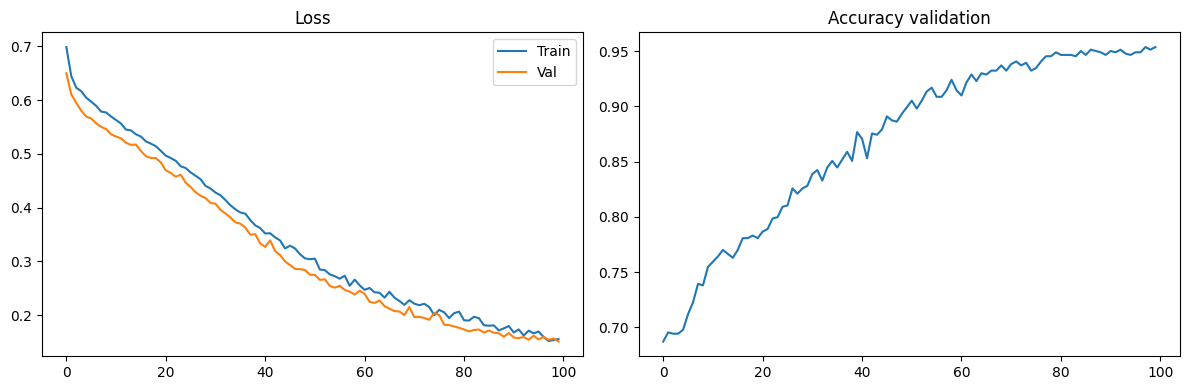

In [ ]:
# ════════════════════════════════════════════
# BLOC 9 — Courbes d'apprentissage
# ════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["val_acc"])
axes[1].set_title("Accuracy validation")

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

In [ ]:
# ════════════════════════════════════════════
# BLOC 10 — Evaluation finale sur le test set
# ════════════════════════════════════════════

resnet.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
resnet.eval()

correct, total = 0, 0
tp, fp, fn     = 0, 0, 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = resnet(imgs).squeeze(1)
        preds  = (torch.sigmoid(logits) > 0.5).float()

        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        tp += ((preds == 1) & (labels == 1)).sum().item()
        fp += ((preds == 1) & (labels == 0)).sum().item()
        fn += ((preds == 0) & (labels == 1)).sum().item()

precision = tp / (tp + fp + 1e-6)
recall    = tp / (tp + fn + 1e-6)
f1        = 2 * precision * recall / (precision + recall + 1e-6)

print(f"\nRésultats sur le test set :")
print(f"  Accuracy  : {correct / total:.4f}")
print(f"  Précision : {precision:.4f}")
print(f"  Rappel    : {recall:.4f}")
print(f"  F1        : {f1:.4f}")


Résultats sur le test set :
  Accuracy  : 0.9414
  Précision : 0.9290
  Rappel    : 0.8947
  F1        : 0.9115


Try MLP

resize images

In [ ]:
# ════════════════════════════════════════════
# BLOC 5 — Chargement de tout le dataset en mémoire
# ════════════════════════════════════════════
from PIL import Image
from torchvision import transforms

print("Chargement de toutes les images...")

all_images = []
all_labels = []

preprocess = transforms.Compose([
  transforms.Resize(32),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
  ])

for img_path, label in items:
    img = Image.open(img_path)
    input_tensor = preprocess(img)

    all_images.append(input_tensor)
    all_labels.append(label)

# Conversion en tenseurs PyTorch
X = torch.stack(all_images)
y = torch.tensor(all_labels, dtype=torch.float32)

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")

Chargement de toutes les images...
Shape X : torch.Size([5630, 3, 32, 32])
Shape y : torch.Size([5630])


In [ ]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms

class MLP(nn.Module):
  '''
    Multilayer Perceptron.
  '''
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      nn.Flatten(),
      nn.Linear(32 * 32 * 3, 128),
      nn.ReLU(),
      nn.Linear(128, 64),
      nn.ReLU(),
      nn.Linear(64, 32),
      nn.ReLU(),
      nn.Linear(32, 2)
      )


  def forward(self, x):
    '''Forward pass'''
    return self.layers(x)


if __name__ == '__main__':

  torch.manual_seed(42)

  train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
  val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

  mlp = MLP()
  loss_function = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-4)

  history = {"train_loss_mlp": [], "val_loss_mlp": [], "val_acc_mlp": []}

  for epoch in range(0, 10):
    print(f'Starting epoch {epoch+1}')

    # --- Training ---
    mlp.train()
    current_loss = 0
    total_train = 0

    for i, data in enumerate(train_loader):
      inputs, targets = data[0], data[1].type(torch.LongTensor)

      optimizer.zero_grad()
      outputs = mlp(inputs)
      loss = loss_function(outputs, targets)
      loss.backward()
      optimizer.step()

      current_loss += loss.item()
      if i % 16 == 15:
        print('Loss after mini-batch %5d: %.3f' % (i + 1, current_loss / 16))
        total_train += current_loss
        current_loss = 0

    history["train_loss_mlp"].append(total_train / len(train_loader))

    # --- Validation ---
    mlp.eval()
    val_loss_mlp = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
      for i, data in enumerate(val_loader):
        inputs, targets = data[0], data[1].type(torch.LongTensor)

        outputs = mlp(inputs)
        outputs = outputs.squeeze(1)
        loss = loss_function(outputs, targets)
        val_loss_mlp += loss.item()

        # Track accuracy
        _, predicted = torch.max(outputs, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

    val_loss_mlp /= len(val_loader)
    val_acc_mlp = correct / total

    history["val_loss_mlp"].append(val_loss_mlp)
    history["val_acc_mlp"].append(val_acc_mlp)

    print(f'Epoch {epoch+1} — Val Loss: {val_loss_mlp:.3f}, Val Acc: {val_acc_mlp:.3f}')

  print('Training process has finished.')

Starting epoch 1
Loss after mini-batch    16: 0.672
Loss after mini-batch    32: 0.613
Loss after mini-batch    48: 0.634
Loss after mini-batch    64: 0.617
Loss after mini-batch    80: 0.580
Loss after mini-batch    96: 0.640
Loss after mini-batch   112: 0.586
Loss after mini-batch   128: 0.603
Loss after mini-batch   144: 0.607
Loss after mini-batch   160: 0.598
Loss after mini-batch   176: 0.633
Loss after mini-batch   192: 0.597
Loss after mini-batch   208: 0.588
Loss after mini-batch   224: 0.598
Loss after mini-batch   240: 0.621
Loss after mini-batch   256: 0.559
Epoch 1 — Val Loss: 0.563, Val Acc: 0.695
Starting epoch 2
Loss after mini-batch    16: 0.572
Loss after mini-batch    32: 0.594
Loss after mini-batch    48: 0.559
Loss after mini-batch    64: 0.596
Loss after mini-batch    80: 0.557
Loss after mini-batch    96: 0.545
Loss after mini-batch   112: 0.532
Loss after mini-batch   128: 0.604
Loss after mini-batch   144: 0.577
Loss after mini-batch   160: 0.571
Loss after min

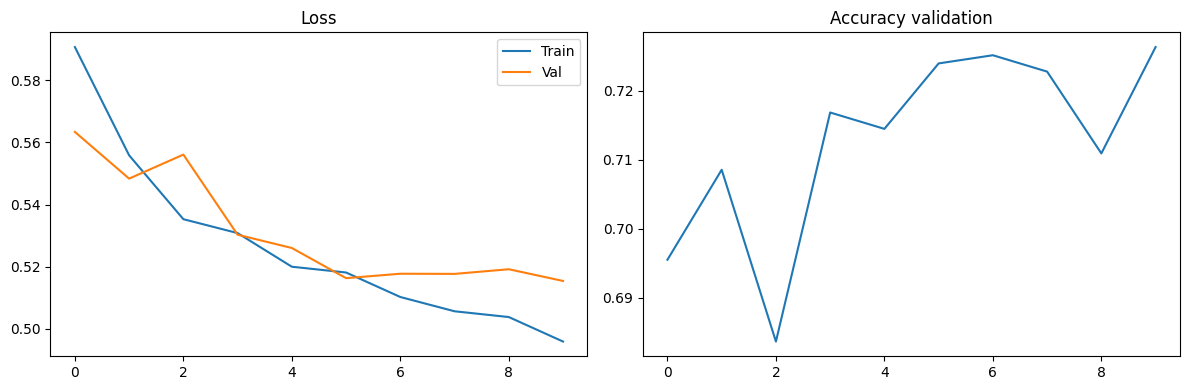

In [ ]:
# ════════════════════════════════════════════
# BLOC 9 — Courbes d'apprentissage
# ════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss_mlp"], label="Train")
axes[0].plot(history["val_loss_mlp"],   label="Val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["val_acc_mlp"])
axes[1].set_title("Accuracy validation")

plt.tight_layout()
plt.show()

Overfitting after 5 epochs, overall not a very good performance.